In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import netCDF4 as nc


In [2]:
df_ameda = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/AMEDA/df_ameda_renamed.pkl')
df_tilt = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/AMEDA/df_tilt_ameda.pkl')
df_ameda = df_ameda.merge(
    df_tilt[['Eddy', 'Day', 'TiltDis', 'TiltDir']],
    how='left',
    left_on=['Eddy', 'Day'],
    right_on=['Eddy', 'Day']
)
df_AE = df_ameda[df_ameda.Cyc=='AE'].copy()
df_CE = df_ameda[df_ameda.Cyc=='CE'].copy()
df_ameda


,Eddy,Day,Cyc,lon,lat,ic,jc,xc,yc,w,...,split2,merge,merge2,shapes2,interaction,interaction2,area,deta,TiltDis,TiltDir
0,1,1462,AE,159.538447,-33.372496,256,186,895.838095,919.548973,0.000010,...,NaN,NaN,NaN,NaN,NaN,NaN,46653.514371,-0.000011,NaN,NaN
1,1,1463,AE,159.686966,-33.160751,257,192,903.002279,946.853133,0.000019,...,NaN,NaN,NaN,NaN,NaN,NaN,4313.383226,-0.000164,NaN,NaN
2,1,1464,AE,159.649836,-33.118402,256,192,898.424872,950.150915,0.000019,...,NaN,NaN,NaN,NaN,NaN,NaN,4336.799061,-0.000070,NaN,NaN
3,1,1465,AE,159.686966,-33.118402,257,193,901.765461,951.353349,0.000019,...,NaN,NaN,NaN,NaN,NaN,NaN,6480.379311,-0.000047,16.147158,80.585819
4,1,1466,AE,159.575577,-32.949006,254,196,886.770848,965.738198,0.000020,...,NaN,NaN,NaN,NaN,NaN,NaN,6101.676103,-0.000401,19.455358,63.680275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104565,3519,10643,CE,154.897235,-28.841152,125,252,327.112431,1244.142958,-0.000014,...,NaN,NaN,NaN,NaN,NaN,NaN,1147.953129,0.000186,8.196140,194.802223
104566,3519,10647,CE,154.860106,-29.052897,127,247,331.141370,1220.843200,-0.000011,...,NaN,NaN,NaN,NaN,NaN,NaN,8038.013328,0.000109,43.813072,358.254256
104567,3519,10648,CE,154.897235,-29.222293,130,244,340.502393,1204.416117,-0.000011,...,NaN,NaN,NaN,NaN,NaN,NaN,9866.414298,0.000095,NaN,NaN
104568,3519,10649,CE,154.377420,-28.417662,100,257,264.105244,1270.945276,-0.000010,...,NaN,NaN,NaN,NaN,NaN,NaN,5581.424065,0.000003,NaN,NaN


In [3]:
fname = f'/srv/scratch/z3533156/26year_BRAN2020/outer_avg_01461.nc'
dataset = nc.Dataset(fname)
lon_rho = np.transpose(dataset.variables['lon_rho'], axes=(1, 0))
lat_rho = np.transpose(dataset.variables['lat_rho'], axes=(1, 0))
mask_rho = np.transpose(dataset.variables['mask_rho'], axes=(1, 0))
h = np.transpose(dataset.variables['h'], axes=(1, 0))
# f = np.transpose(dataset.variables['f'], axes=(1, 0))
angle = dataset.variables['angle'][0, 0]
z_r = np.load('/srv/scratch/z5297792/z_r.npy')
z_r = np.transpose(z_r, (1, 2, 0))
def distance(lat1, lon1, lat2, lon2):
    EARTH_RADIUS = 6357
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return EARTH_RADIUS * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
j_mid, i_mid = lon_rho.shape[1] // 2, lon_rho.shape[0] // 2
dx = distance(lat_rho[:-1, j_mid], lon_rho[:-1, j_mid],
              lat_rho[1:, j_mid], lon_rho[1:, j_mid])
dy = distance(lat_rho[i_mid, :-1], lon_rho[i_mid, :-1],
              lat_rho[i_mid, 1:], lon_rho[i_mid, 1:])
x_grid = np.insert(np.cumsum(dx), 0, 0)
y_grid = np.insert(np.cumsum(dy), 0, 0)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid, indexing='ij')


In [4]:
df_TDis_ave = pd.DataFrame(columns=['Eddy', 'Cyc', 'ave_TDis', 'min_TDis', 'max_TDis'])
for eddy in df_ameda.Eddy.unique():
    df = df_ameda[df_ameda.Eddy==eddy].copy()
    df = df[~df.TiltDis.isna()]
    if len(df) >= 30:
        df_TDis_ave.loc[len(df_TDis_ave)] = {'Eddy': eddy, 'Cyc': df.iloc[0].Cyc, 'ave_TDis': df.TiltDis.mean(),
                                            'min_TDis': df.TiltDis.min(), 'max_TDis': df.TiltDis.max()}
df_TDis_ave = df_TDis_ave.dropna()
df_TDis_ave_AE = df_TDis_ave[df_TDis_ave.Cyc=='AE']
df_TDis_ave_CE = df_TDis_ave[df_TDis_ave.Cyc=='CE']
df_TDis_ave


,Eddy,Cyc,ave_TDis,min_TDis,max_TDis
0,1,AE,19.641817,3.289195,38.623869
1,2,AE,48.543217,19.716579,103.085758
2,5,AE,7.249470,0.327291,58.222426
3,6,AE,29.540898,3.054178,116.483035
4,9,AE,28.865959,2.630456,68.654900
...,...,...,...,...,...
684,3486,AE,2.261175,0.264070,5.916878
685,3497,AE,42.417475,4.408584,169.076246
686,3498,AE,24.937386,2.117418,65.536825
687,3504,CE,9.944101,0.031686,40.982299


In [5]:
def circular_mean_deg_true_north(deg):
    deg = np.asarray(deg)
    r = np.deg2rad(deg)
    C = np.mean(np.cos(r))
    S = np.mean(np.sin(r))
    return np.rad2deg(np.arctan2(S, C)) % 360 

df_TDir_ave = pd.DataFrame(columns=['Eddy', 'Cyc', 'ave_TDir'])
for eddy in df_ameda.Eddy.unique():
    df = df_ameda[df_ameda.Eddy==eddy].copy()
    df = df[~df.TiltDis.isna()]
    if len(df) >= 30:
        df_TDir_ave.loc[len(df_TDir_ave)] = {'Eddy': eddy, 'Cyc': df.iloc[0].Cyc, 'ave_TDir': circular_mean_deg_true_north(df.TiltDir)}
df_TDir_ave = df_TDir_ave.dropna()
df_TDir_ave_AE = df_TDir_ave[df_TDir_ave.Cyc=='AE']
df_TDir_ave_CE = df_TDir_ave[df_TDir_ave.Cyc=='CE']
df_TDir_ave


,Eddy,Cyc,ave_TDir
0,1,AE,27.643241
1,2,AE,330.173932
2,5,AE,314.176442
3,6,AE,18.953655
4,9,AE,14.035904
...,...,...,...
684,3486,AE,103.713864
685,3497,AE,111.328040
686,3498,AE,11.413060
687,3504,CE,242.405751


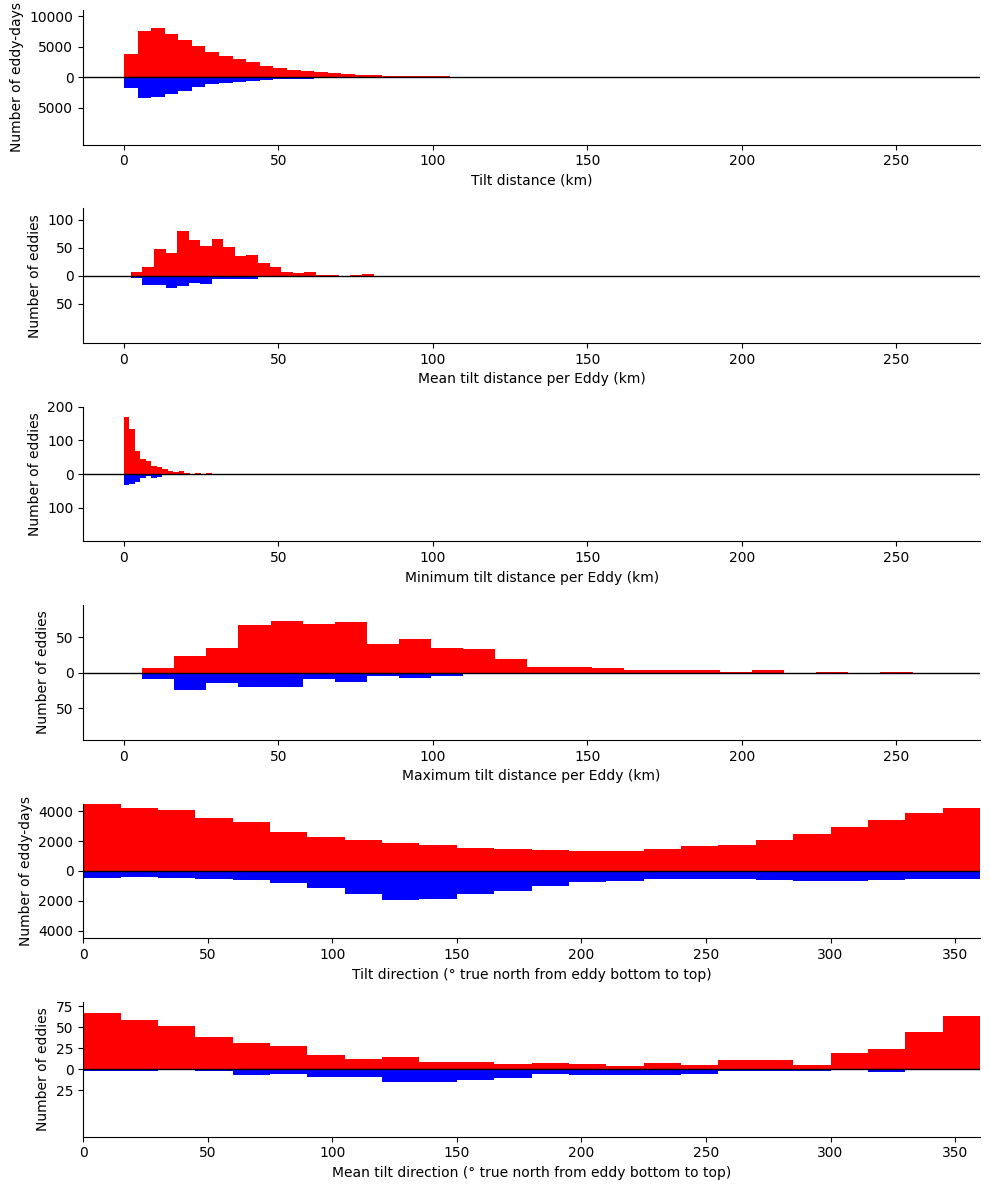

In [6]:
fig, axs = plt.subplots(6, 1, figsize=(10, 12))

def clean(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    return a[np.isfinite(a)], b[np.isfinite(b)]

def shared_bins(a, b, method='fd', min_bins=12, max_bins=40):
    a, b = clean(a, b)
    all_vals = np.concatenate([a, b])
    edges = np.histogram_bin_edges(all_vals, bins=method)
    
    n_bins = len(edges) - 1
    if n_bins < min_bins:
        edges = np.linspace(all_vals.min(), all_vals.max(), min_bins + 1)
    elif n_bins > max_bins:
        edges = np.linspace(all_vals.min(), all_vals.max(), max_bins + 1)
    return edges

def mirrored_hist(ax, ae, ce, bins, xlabel, ylabel, ylim=None, xlim=None):
    ae, ce = clean(ae, ce)
    
    ax.hist(ae, bins=bins, color='r')
    counts, edges = np.histogram(ce, bins=bins)
    ax.bar(edges[:-1], -counts, width=np.diff(edges), color='b', align='edge')
    
    ax.axhline(0, color='k', linewidth=1)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_yticks(ax.get_yticks())
    ax.set_yticklabels([abs(int(t)) for t in ax.get_yticks()])
    
    if ylim is not None:
        ax.set_ylim(ylim)
    if xlim is not None:
        ax.set_xlim(xlim)

# --- Plot 0 ---
bins0 = shared_bins(df_AE.TiltDis, df_CE.TiltDis, method='fd', min_bins=20, max_bins=60)
mirrored_hist(
    axs[0],
    df_AE.TiltDis,
    df_CE.TiltDis,
    bins0,
    'Tilt distance (km)',
    'Number of eddy-days',
    ylim=(-11000, 11000)
)

# --- Plot 1 ---
bins1 = shared_bins(df_TDis_ave_AE.ave_TDis, df_TDis_ave_CE.ave_TDis, method='fd', min_bins=12, max_bins=30)
mirrored_hist(
    axs[1],
    df_TDis_ave_AE.ave_TDis,
    df_TDis_ave_CE.ave_TDis,
    bins1,
    'Mean tilt distance per Eddy (km)',
    'Number of eddies',
    ylim=(-120, 120),
    xlim=axs[0].get_xlim()
)

# --- Plot 2 ---
bins2 = shared_bins(df_TDis_ave_AE.min_TDis, df_TDis_ave_CE.min_TDis, method='fd', min_bins=12, max_bins=30)
mirrored_hist(
    axs[2],
    df_TDis_ave_AE.min_TDis,
    df_TDis_ave_CE.min_TDis,
    bins2,
    'Minimum tilt distance per Eddy (km)',
    'Number of eddies',
    ylim=(-200, 200),
    xlim=axs[0].get_xlim()
)

# --- Plot 3 ---
bins3 = shared_bins(df_TDis_ave_AE.max_TDis, df_TDis_ave_CE.max_TDis, method='fd', min_bins=12, max_bins=30)
mirrored_hist(
    axs[3],
    df_TDis_ave_AE.max_TDis,
    df_TDis_ave_CE.max_TDis,
    bins3,
    'Maximum tilt distance per Eddy (km)',
    'Number of eddies',
    ylim=(-95, 95),
    xlim=axs[0].get_xlim()
)

# --- Plot 4 ---
# For direction, fixed bins are better than "optimised" bins because the variable is angular
bins4 = np.arange(0, 361, 15)
mirrored_hist(
    axs[4],
    df_AE.TiltDir % 360,
    df_CE.TiltDir % 360,
    bins4,
    'Tilt direction (° true north from eddy bottom to top)',
    'Number of eddy-days',
    ylim=(-4500, 4500),
    xlim=(0, 360)
)

# --- Plot 5 ---
bins5 = np.arange(0, 361, 15)
mirrored_hist(
    axs[5],
    df_TDir_ave_AE.ave_TDir % 360,
    df_TDir_ave_CE.ave_TDir % 360,
    bins5,
    'Mean tilt direction (° true north from eddy bottom to top)',
    'Number of eddies',
    ylim=(-80, 80),
    xlim=(0, 360)
)

plt.tight_layout()
plt.show()
